# EconAgent (econargent/AutoGen) — Análisis de resultados (Nova Lite / Bedrock)

Análisis de la corrida `gpt-autogen-bedrock-amazon.nova-lite-v1-0-3-noperception-reflection-1-100agents-240months` (carpeta `data/` de `econargent`): backend `ECON_BACKEND=bedrock`, modelo `amazon.nova-lite-v1:0`, 100 agentes, 240 meses, `dialog_len=3`. A diferencia de `ACL24-EconAgent`, la llamada al LLM pasa por el framework **AutoGen** (`autogen_providers.py`, cliente `SKChatCompletionAdapter` sobre Semantic Kernel para Bedrock) en vez de llamar directo al SDK de boto3 — la lógica de simulación económica (`ai_economist/`) es la misma.

Mismo formato que `analysis.ipynb`/`analysis_novalite_100agents_240months.ipynb` de `ACL24-EconAgent`, para poder comparar resultados entre el framework original y el port a AutoGen. Los archivos en `data/` son todos generados por la corrida, salvo `profiles.json` (copiado del framework original, no se regenera acá).

In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 4)

# Examinamos los archivos

 Descripción de Archivos

| Archivo / Carpeta | Descripción |
| :--- | :--- |
| `env_6.pkl`, `env_12.pkl` | El objeto `env` completo (estado de Foundation) serializado en el paso 6 y 12. |
| `obs_6.pkl`, `obs_12.pkl` | La observación devuelta por el `env` en ese paso. |
| `actions_6.pkl`, `actions_12.pkl` | Las acciones `[work, consumption]` decodificadas del JSON del LLM para cada agente. |
| `dialog_6.pkl`, `dialog_12.pkl` | La cola corta de diálogo (`dialog_queue`, `maxlen=3`) que se manda como contexto al LLM en cada llamada. |
| `dialog4ref_6.pkl`, `dialog4ref_12.pkl` | La cola larga de diálogo (`maxlen=7`) que alimenta las reflexiones trimestrales. |
| `dense_log.pkl`, `dense_log_6.pkl`, `dense_log_12.pkl` | El log denso de Foundation: histórico completo de estados/acciones/recompensas de la simulación, paso a paso (esto es lo que analiza este notebook). |
| `dialogs/` | Carpeta con un archivo de texto por agente (nombre del agente = nombre del archivo), con el historial completo de la conversación en texto plano (lo que escribe `simulate.py:127-130`) — útil para leer "a mano" qué le contestó el LLM a cada agente mes a mes. |

**Nota sobre el nombre de la carpeta**: en este fork, `current_model_tag()` (`autogen_providers.py`) sí incluye el backend y el modelo en el nombre — `{policy_model}-autogen-{backend}-{modelo}-{dialog_len}-noperception-reflection-1-{num_agents}agents-{episode_length}months` — así que una corrida con otro backend/modelo no pisa esta carpeta.

## 1. Cargar resultados

In [2]:
# Listá las simulaciones disponibles (data/ está un nivel arriba: este notebook vive en analisis/)
data_dir = Path('../data')
runs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
for i, r in enumerate(runs):
    print(f'[{i}] {r.name}')


[0] gpt-autogen-bedrock-amazon.nova-lite-v1-0-3-noperception-reflection-1-100agents-240months


In [3]:
# Corrida hecha con econargent (AutoGen + Bedrock, amazon.nova-lite-v1:0, 100 agentes, 240 meses, dialog_len=3)
RUN_NAME = 'gpt-autogen-bedrock-amazon.nova-lite-v1-0-3-noperception-reflection-1-100agents-240months'
run_path = next(r for r in runs if r.name == RUN_NAME)
print(f'Analizando: {run_path.name}')

with open(run_path / 'dense_log.pkl', 'rb') as f:
    log = pkl.load(f)

print('\nClaves disponibles en dense_log:')
print(list(log.keys()))


Analizando: gpt-autogen-bedrock-amazon.nova-lite-v1-0-3-noperception-reflection-1-100agents-240months

Claves disponibles en dense_log:
['world', 'states', 'actions', 'rewards', 'PeriodicTax']


**Metadata de la corrida**:
- Framework: `econargent` (AutoGen) — backend `bedrock`, modelo `amazon.nova-lite-v1:0` vía `SKChatCompletionAdapter`
- 100 agentes, 240 meses, `dialog_len=3`

**⚠️ Bug de pricing conocido (heredado de ACL24-EconAgent)**: el costo que imprime la consola se calcula con `PRICE_INPUT_PER_1M` / `PRICE_OUTPUT_PER_1M` de `.env`. Al momento de esta corrida esas variables seguían en **$3 / $15 por 1M tokens (precio de Claude Sonnet 4.6)**, no el de Nova Lite (que en Bedrock ronda $0.06 / $0.24 por 1M — unas 50x más barato). El costo real de la corrida es varias veces menor al reportado por consola; para un número confiable, corregir esas variables (o agregar `amazon.nova-lite-v1:0` al diccionario `PRICING` de `autogen_providers.py`) antes de la próxima corrida y usar `get_usage_summary()`.

In [4]:
from pprint import pprint

actions_6_path = run_path / 'actions_6.pkl'

if actions_6_path.exists():
    with open(actions_6_path, 'rb') as f:
        actions_6 = pkl.load(f)
    print(f'Archivo cargado: {actions_6_path.name}')
else:
    actions_6 = log.get('actions_6', None)
    print('No se encontró actions_6.pkl; usando log["actions_6"] si existe.')

print('Tipo:', type(actions_6))

if isinstance(actions_6, pd.DataFrame):
    display(actions_6)
elif isinstance(actions_6, (list, tuple)):
    pprint(actions_6[:5])
    print(f'Longitud: {len(actions_6)}')
elif isinstance(actions_6, dict):
    pprint(actions_6)
else:
    print(actions_6)

Archivo cargado: actions_6.pkl
Tipo: <class 'dict'>
{'0': [1, 49.0],
 '1': [1, 46.99999999999999],
 '10': [1, 33.0],
 '11': [1, 49.0],
 '12': [1, 43.0],
 '13': [1, 49.0],
 '14': [1, 45.0],
 '15': [1, 42.0],
 '16': [1, 41.0],
 '17': [1, 12.0],
 '18': [1, 35.0],
 '19': [1, 38.0],
 '2': [1, 45.0],
 '20': [1, 42.0],
 '21': [1, 49.0],
 '22': [1, 26.0],
 '23': [1, 46.0],
 '24': [1, 42.0],
 '25': [1, 48.0],
 '26': [1, 35.0],
 '27': [1, 44.0],
 '28': [0, 50.0],
 '29': [1, 34.0],
 '3': [1, 38.0],
 '30': [1, 28.999999999999996],
 '31': [1, 28.000000000000004],
 '32': [1, 49.0],
 '33': [1, 50.0],
 '34': [0, 8.0],
 '35': [1, 37.0],
 '36': [1, 46.0],
 '37': [1, 50.0],
 '38': [1, 26.0],
 '39': [1, 42.0],
 '4': [1, 50.0],
 '40': [1, 35.0],
 '41': [1, 36.0],
 '42': [1, 19.0],
 '43': [1, 44.0],
 '44': [0, 41.0],
 '45': [1, 45.0],
 '46': [1, 50.0],
 '47': [1, 49.0],
 '48': [1, 44.0],
 '49': [1, 50.0],
 '5': [1, 46.0],
 '50': [1, 42.0],
 '51': [1, 18.0],
 '52': [1, 45.0],
 '53': [1, 24.0],
 '54': [0, 43.

archivo actions_6.pkl muestra los agentes y el gobierno (p de planner) con las decisiones de trabajo/consumo del mes 6.
### 1. El LLM devuelve un porcentaje (0 a 1)
El prompt le pide al LLM: "'consumption' (a value between 0 and 1 with intervals of 0.02)" — es decir, algo como 0.5 = "quiero gastar el 50% de mis ahorros+ingreso disponible en bienes esenciales".

### 2. simulate.py convierte ese porcentaje en un índice discreto

extracted_actions[1] /= 0.02
(simulate.py:122)

Si el LLM contestó consumption = 0.5, esto hace 0.5 / 0.02 = 25. Ese 25 es el número que terminás viendo guardado en actions_6.pkl. No es "25 dólares" ni "25%" — es un índice de acción discreta dentro de una grilla de 50 posiciones (n_actions = 1.0/0.02 = 50, simple_consumption.py:35).

### 3. Foundation vuelve a convertir ese índice en tasa real
Cuando Foundation ejecuta el step, el componente SimpleConsumption toma esa acción (action=25) y hace la operación inversa:


consumption_rate = action * self.consumption_rate_step   # 25 * 0.02 = 0.5
(simple_consumption.py:84)

Es decir: 25 × 0.02 = 0.5 → 50% de la tasa de consumo, que es exactamente el mismo porcentaje que el LLM dijo originalmente en el prompt.

Por qué existe este ida y vuelta
Foundation (heredado del paper RL original) espera acciones discretas porque las redes de política PPO tienen una cabeza de clasificación (softmax sobre 50 categorías), no un valor continuo. El LLM en cambio razona más naturalmente en porcentajes continuos (0 a 1). Entonces:

LLM → índice: se divide por 0.02 para "encajar" la respuesta continua del LLM en la grilla discreta de 50 acciones que espera el motor de Foundation.
índice → efecto real: Foundation multiplica por 0.02 de vuelta para recuperar la tasa real y calcular cuánto dinero gasta el agente ese mes.
En resumen: el valor guardado en el .pkl es un artefacto de codificación intermedio (el índice de acción), y su significado económico real es simplemente índice × 0.02 = proporción gastada ese mes.

## 2. Extraer series de tiempo

In [5]:
T = len(log['states'])
n_agents = len([k for k in log['states'][0].keys() if k != 'p'])
print(f'Pasos: {T}   Agentes: {n_agents}')

# --- Macroeconómicos (world) ---
world_df = pd.DataFrame(log['world'])
world_df.index.name = 'step'

# --- Estados de agentes ---
wealth    = np.array([[log['states'][t][str(i)]['inventory']['Coin']  for i in range(n_agents)] for t in range(T)])
income    = np.array([[log['states'][t][str(i)].get('income', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
skill     = np.array([[log['states'][t][str(i)]['skill']               for i in range(n_agents)] for t in range(T)])

print('world_df columnas:', list(world_df.columns))

Pasos: 241   Agentes: 100
world_df columnas: ['Price', '#Products', 'Interest Rate', 'Unemployment Rate', 'Real GDP', 'Nominal GDP', 'Price Inflation', 'Unemployment Rate Growth', 'Wage Inflation', 'Nominal GDP Growth', 'Real GDP Growth']


## 3. Indicadores macroeconómicos

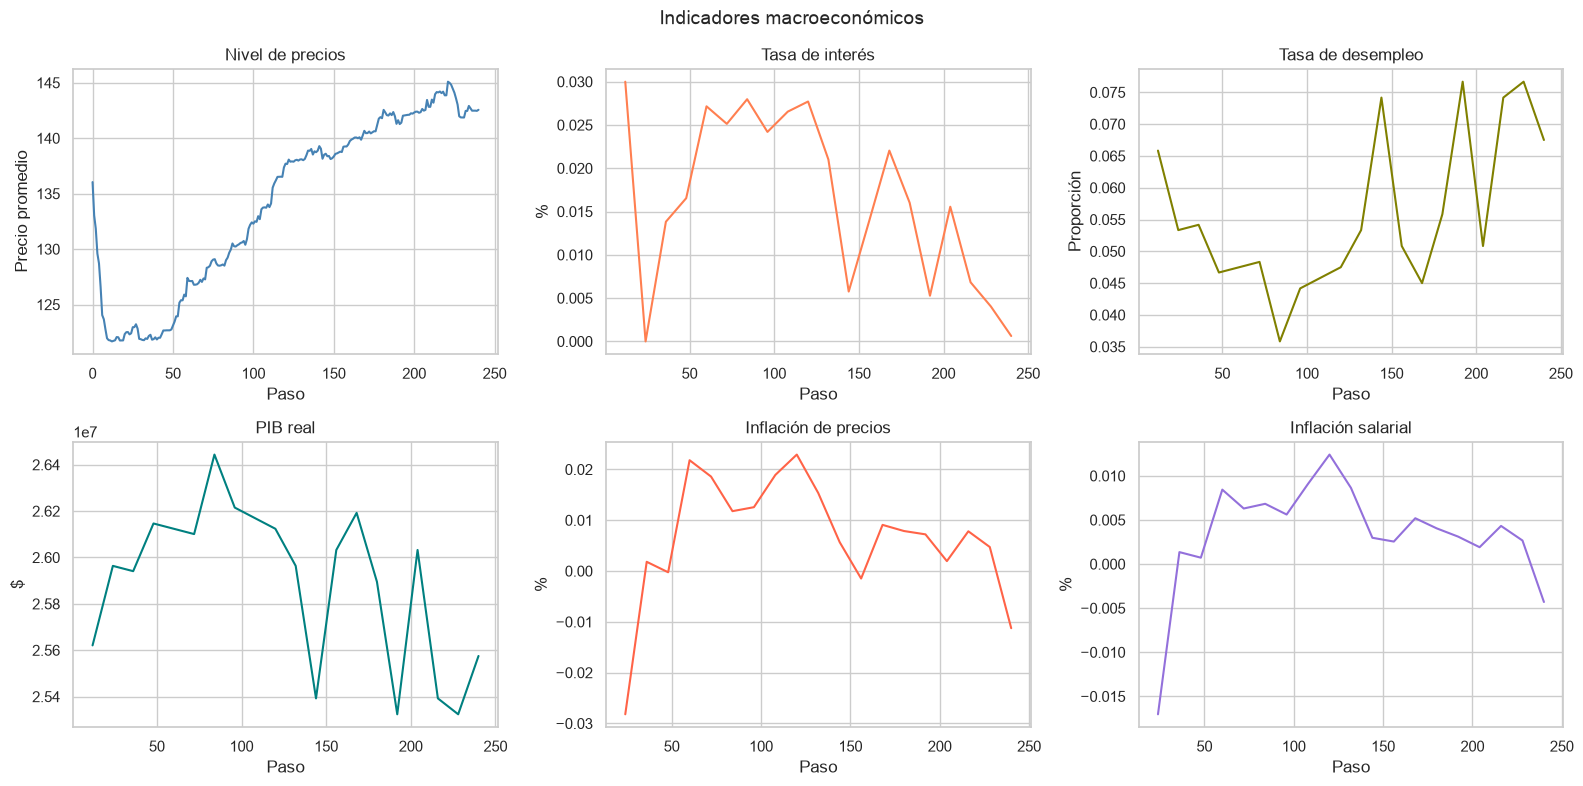

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Indicadores macroeconómicos', fontsize=14)
steps = range(T)

def plot_series(ax, series, title, ylabel, color='steelblue'):
    clean = series.dropna()
    ax.plot(clean.index, clean.values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Paso')

plot_series(axes[0,0], world_df['Price'],           'Nivel de precios',      'Precio promedio')
plot_series(axes[0,1], world_df.get('Interest Rate', pd.Series(dtype=float)), 'Tasa de interés', '%', color='coral')
plot_series(axes[0,2], world_df.get('Unemployment Rate', pd.Series(dtype=float)), 'Tasa de desempleo', 'Proporción', color='olive')
plot_series(axes[1,0], world_df.get('Real GDP', pd.Series(dtype=float)),       'PIB real',      '$', color='teal')
plot_series(axes[1,1], world_df.get('Price Inflation', pd.Series(dtype=float)), 'Inflación de precios', '%', color='tomato')
plot_series(axes[1,2], world_df.get('Wage Inflation', pd.Series(dtype=float)),  'Inflación salarial',  '%', color='mediumpurple')

plt.tight_layout()
plt.show()

## 4. Distribución de riqueza

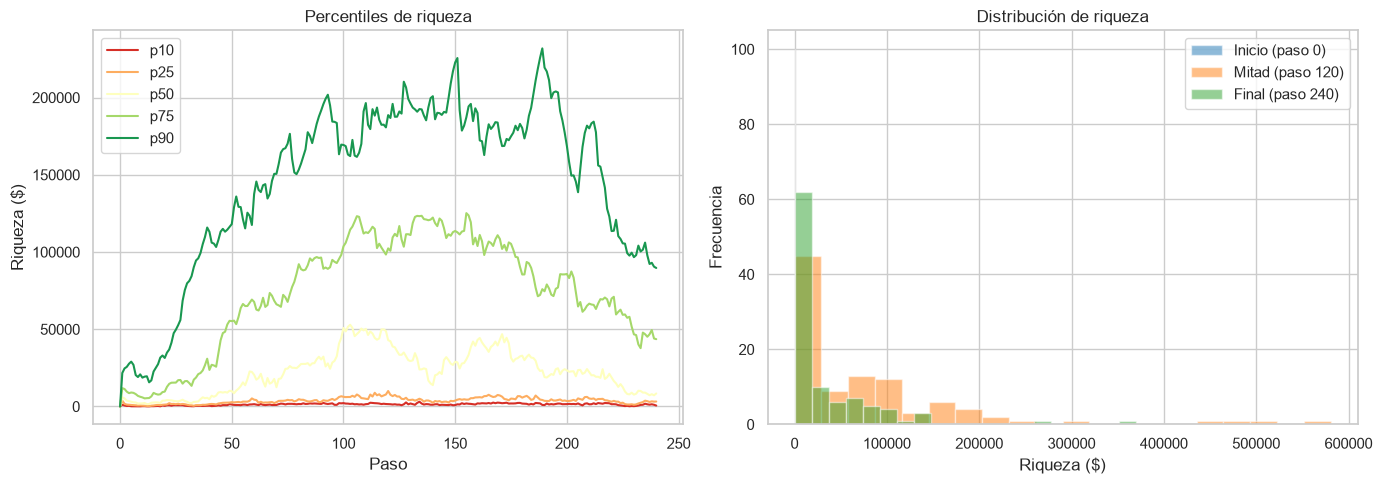

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentiles de riqueza a lo largo del tiempo
ax = axes[0]
quantiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(quantiles)))
for q, c in zip(quantiles, colors):
    ax.plot(np.percentile(wealth, q, axis=1), label=f'p{q}', color=c)
ax.set_title('Percentiles de riqueza')
ax.set_xlabel('Paso')
ax.set_ylabel('Riqueza ($)')
ax.legend()

# Distribución al inicio, mitad y final
ax = axes[1]
checkpoints = [0, T//2, T-1]
labels = ['Inicio', 'Mitad', 'Final']
for cp, label in zip(checkpoints, labels):
    ax.hist(wealth[cp], bins=20, alpha=0.5, label=f'{label} (paso {cp})')
ax.set_title('Distribución de riqueza')
ax.set_xlabel('Riqueza ($)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Coeficiente de Gini

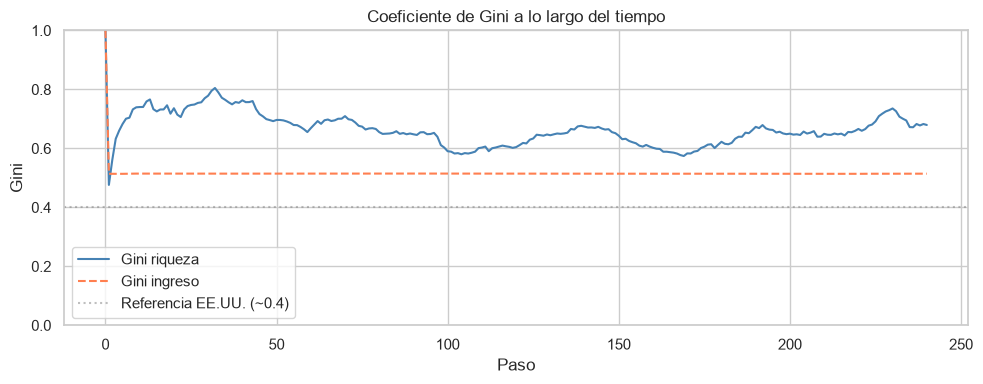

Gini riqueza  — inicio: 1.000  |  final: 0.679
Gini ingreso  — inicio: 1.000  |  final: 0.514


In [8]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return 1 - (2 / (n + 1)) * np.sum(np.cumsum(x) / (np.sum(x) + 1e-10))

gini_wealth = [gini(wealth[t]) for t in range(T)]
gini_income = [gini(income[t]) for t in range(T)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_wealth, label='Gini riqueza', color='steelblue')
ax.plot(gini_income, label='Gini ingreso', color='coral', linestyle='--')
ax.set_ylim(0, 1)
ax.set_title('Coeficiente de Gini a lo largo del tiempo')
ax.set_xlabel('Paso')
ax.set_ylabel('Gini')
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='Referencia EE.UU. (~0.4)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gini riqueza  — inicio: {gini_wealth[0]:.3f}  |  final: {gini_wealth[-1]:.3f}')
print(f'Gini ingreso  — inicio: {gini_income[0]:.3f}  |  final: {gini_income[-1]:.3f}')

## 6. Curva de Lorenz (inicio vs final)

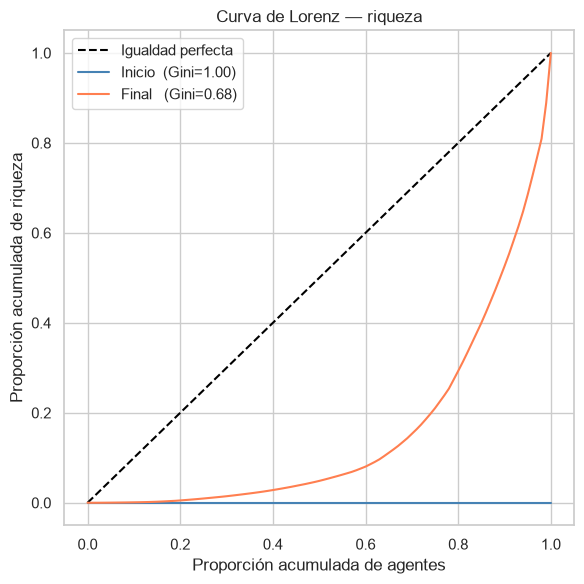

In [9]:
def lorenz(x):
    x = np.sort(np.abs(x))
    cum = np.cumsum(x) / (np.sum(x) + 1e-10)
    return np.concatenate([[0], cum])

fig, ax = plt.subplots(figsize=(6, 6))
pop = np.linspace(0, 1, n_agents + 1)

ax.plot([0, 1], [0, 1], 'k--', label='Igualdad perfecta')
ax.plot(pop, lorenz(wealth[0]),   label=f'Inicio  (Gini={gini_wealth[0]:.2f})',  color='steelblue')
ax.plot(pop, lorenz(wealth[-1]),  label=f'Final   (Gini={gini_wealth[-1]:.2f})', color='coral')

ax.set_title('Curva de Lorenz — riqueza')
ax.set_xlabel('Proporción acumulada de agentes')
ax.set_ylabel('Proporción acumulada de riqueza')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Actividad laboral y consumo

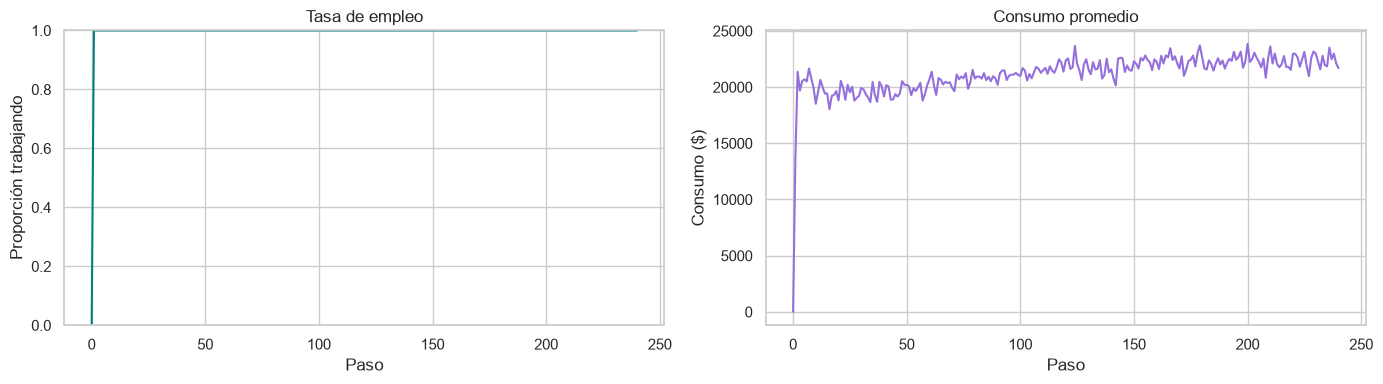

In [10]:
# Tasa de empleo: proporción de agentes que trabajaron en cada paso
if 'SimpleLabor' in log:
    labor_log = log['SimpleLabor']
    labor_rate = [np.mean([a > 0 for a in step.values()]) if isinstance(step, dict) else np.mean(np.array(step) > 0) for step in labor_log]
else:
    labor_rate = [np.mean(income[t] > 0) for t in range(T)]

# Consumo promedio
consumption = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
mean_consumption = consumption.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(labor_rate, color='teal')
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de empleo')
axes[0].set_xlabel('Paso')
axes[0].set_ylabel('Proporción trabajando')

axes[1].plot(mean_consumption, color='mediumpurple')
axes[1].set_title('Consumo promedio')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Consumo ($)')

plt.tight_layout()
plt.show()

## 8. Impuestos y redistribución

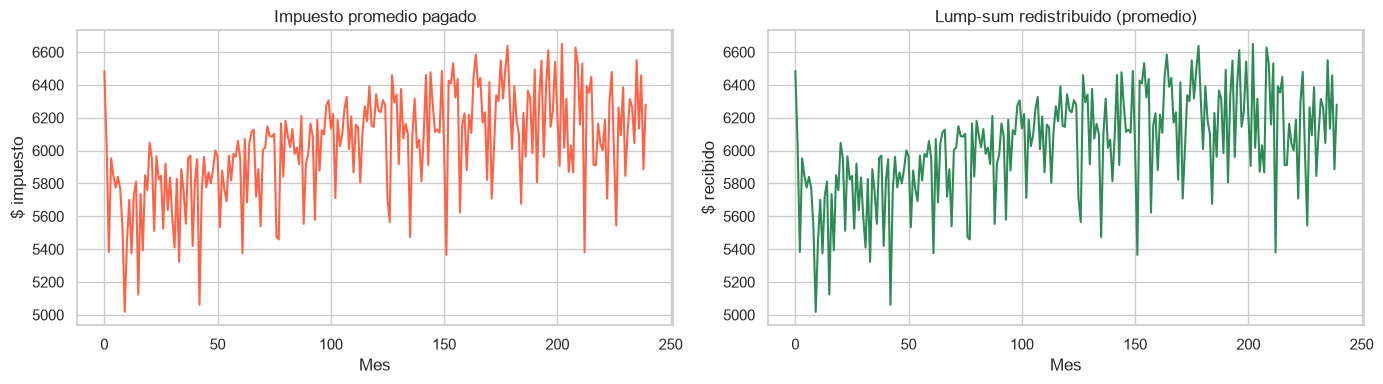

In [11]:
# El componente de impuestos loguea bajo la clave 'PeriodicTax' (no '...BracketTax-tax_paid'
# como en versiones previas): una lista de 240 dicts, cada uno con 'schedule'/'cutoffs' más
# una entrada por agente ('0'..'n') con 'income'/'tax_paid'/'marginal_rate'/'effective_rate'/'lump_sum'.
tax_log = log.get('PeriodicTax')

if tax_log:
    agent_keys = [k for k in tax_log[0].keys() if k not in ('schedule', 'cutoffs')]
    tax_paid_series = np.array([[step[a]['tax_paid'] for a in agent_keys] for step in tax_log])
    lump_sum_series = np.array([[step[a]['lump_sum'] for a in agent_keys] for step in tax_log])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(tax_paid_series.mean(axis=1), color='tomato')
    axes[0].set_title('Impuesto promedio pagado')
    axes[0].set_xlabel('Mes')
    axes[0].set_ylabel('$ impuesto')

    axes[1].plot(lump_sum_series.mean(axis=1), color='seagreen')
    axes[1].set_title('Lump-sum redistribuido (promedio)')
    axes[1].set_xlabel('Mes')
    axes[1].set_ylabel('$ recibido')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos de impuestos en el dense_log.')
    print('Claves disponibles:', [k for k in log.keys() if 'Tax' in k or 'tax' in k])


## 9. Resumen estadístico

In [12]:
summary = pd.DataFrame({
    'Riqueza media':       wealth.mean(axis=1),
    'Riqueza mediana':     np.median(wealth, axis=1),
    'Riqueza std':         wealth.std(axis=1),
    'Ingreso medio':       income.mean(axis=1),
    'Consumo medio':       mean_consumption,
    'Gini riqueza':        gini_wealth,
    'Gini ingreso':        gini_income,
})

print('=== Estadísticas al INICIO ===')
print(summary.iloc[0].to_string())
print('\n=== Estadísticas al FINAL ===')
print(summary.iloc[-1].to_string())

=== Estadísticas al INICIO ===
Riqueza media      0.0
Riqueza mediana    0.0
Riqueza std        0.0
Ingreso medio      0.0
Consumo medio      0.0
Gini riqueza       1.0
Gini ingreso       1.0

=== Estadísticas al FINAL ===
Riqueza media      33354.868748
Riqueza mediana     8423.951609
Riqueza std        55011.016239
Ingreso medio      23376.012409
Consumo medio      21690.965653
Gini riqueza           0.679449
Gini ingreso           0.514209


## 10. Curva de Phillips y Ley de Okun (validación vs. el paper)

El paper original usa estas dos regularidades como principal criterio de plausibilidad (Figura 3): correlación negativa entre desempleo e inflación salarial (Phillips) y entre crecimiento del desempleo y crecimiento del PIB real (Okun). Reportan Pearson r=-0.619 (p<0.01) y r=-0.918 (p<0.001) respectivamente para EconAgent con gpt-3.5-turbo-0613, muy superior a los baselines rule-based/RL.

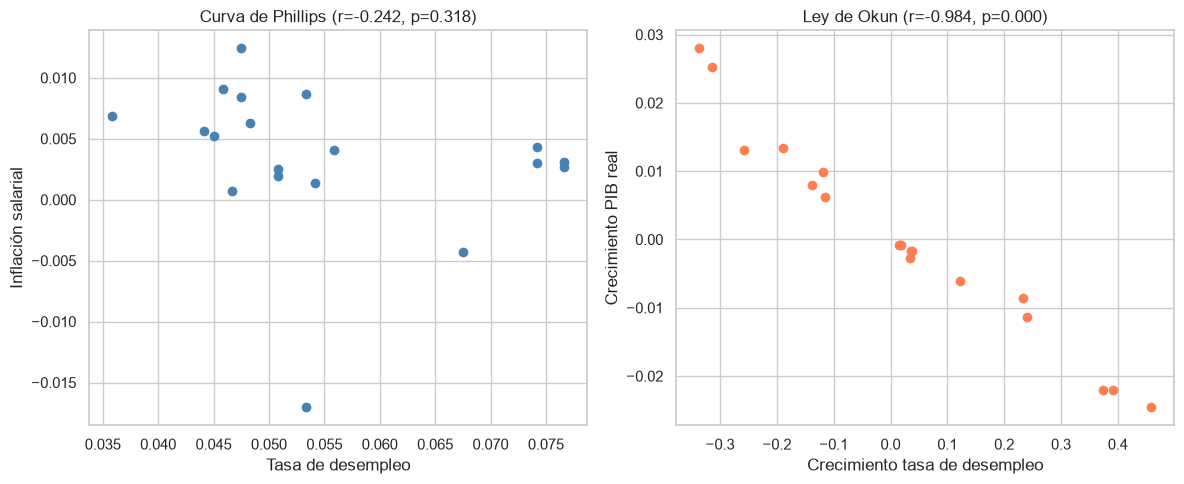

Phillips: r=-0.242  p=0.3182   (paper gpt-3.5: r=-0.619, p<0.01)
Okun:     r=-0.984  p=0.0000   (paper gpt-3.5: r=-0.918, p<0.001)


In [13]:
from scipy.stats import pearsonr

unemp_a = world_df['Unemployment Rate'].dropna()
wage_infl_a = world_df['Wage Inflation'].dropna()
unemp_growth_a = world_df['Unemployment Rate Growth'].dropna()
gdp_growth_a = world_df['Real GDP Growth'].dropna()

# Alinear por índice (mismos steps anuales)
phillips = pd.concat([unemp_a, wage_infl_a], axis=1).dropna()
okun = pd.concat([unemp_growth_a, gdp_growth_a], axis=1).dropna()

r_phillips, p_phillips = pearsonr(phillips.iloc[:,0], phillips.iloc[:,1])
r_okun, p_okun = pearsonr(okun.iloc[:,0], okun.iloc[:,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(phillips.iloc[:,0], phillips.iloc[:,1], color='steelblue')
axes[0].set_title(f'Curva de Phillips (r={r_phillips:.3f}, p={p_phillips:.3f})')
axes[0].set_xlabel('Tasa de desempleo')
axes[0].set_ylabel('Inflación salarial')

axes[1].scatter(okun.iloc[:,0], okun.iloc[:,1], color='coral')
axes[1].set_title(f"Ley de Okun (r={r_okun:.3f}, p={p_okun:.3f})")
axes[1].set_xlabel('Crecimiento tasa de desempleo')
axes[1].set_ylabel('Crecimiento PIB real')

plt.tight_layout()
plt.show()

print(f'Phillips: r={r_phillips:.3f}  p={p_phillips:.4f}   (paper gpt-3.5: r=-0.619, p<0.01)')
print(f'Okun:     r={r_okun:.3f}  p={p_okun:.4f}   (paper gpt-3.5: r=-0.918, p<0.001)')

## 11. Comparación de rangos con el paper

El paper reporta (Figura 2, texto sección 4.2, con gpt-3.5-turbo-0613):
- Inflación anual: estable entre -5% y 5% después del año 3.
- Desempleo: generalmente entre 2% y 12%.
- PIB nominal y su crecimiento dentro de límites "razonables" (sin cuantificar rango exacto).

In [14]:
infl = world_df['Price Inflation'].dropna()
unemp = world_df['Unemployment Rate'].dropna()

print('=== Esta corrida (econargent, AutoGen + Nova Lite) ===')
print(f'Inflación anual:  min {infl.min():.3%}  max {infl.max():.3%}')
print(f'Desempleo anual:  min {unemp.min():.3%}  max {unemp.max():.3%}')
print()
print('=== Paper (gpt-3.5-turbo-0613) ===')
print('Inflación anual:  banda -5% a 5% (después del año 3)')
print('Desempleo anual:  banda ~2% a 12%')

=== Esta corrida (econargent, AutoGen + Nova Lite) ===
Inflación anual:  min -2.820%  max 2.292%
Desempleo anual:  min 3.583%  max 7.667%

=== Paper (gpt-3.5-turbo-0613) ===
Inflación anual:  banda -5% a 5% (después del año 3)
Desempleo anual:  banda ~2% a 12%


## 12. Diagnóstico: ¿por qué no se replica la curva de Phillips?

Hipótesis: el signo de Phillips en este entorno depende de si el consumo agregado reacciona al desempleo (si la demanda cae cuando sube el desempleo, hay superávit de bienes y los salarios bajan → Phillips correcto; si el consumo se mantiene rígido, hay faltante y los salarios suben → Phillips al revés).

Usamos `log['actions']` (decisión real `[SimpleLabor, SimpleConsumption]` de cada agente, cada uno de los 240 meses — no una sola muestra como `actions_6.pkl`) para testear esto con mucha más potencia estadística que las 20 observaciones anuales.

In [15]:
T_a = len(log['actions'])
work_raw = np.array([[log['actions'][t][str(i)].get('SimpleLabor', 0)       for i in range(n_agents)] for t in range(T_a)])
cons_raw = np.array([[log['actions'][t][str(i)].get('SimpleConsumption', 0) for i in range(n_agents)] for t in range(T_a)])

n_missing_labor = sum(1 for t in range(T_a) for i in range(n_agents) if 'SimpleLabor' not in log['actions'][t][str(i)])
n_missing_cons  = sum(1 for t in range(T_a) for i in range(n_agents) if 'SimpleConsumption' not in log['actions'][t][str(i)])
print(f'Observaciones agente-mes: {work_raw.size}')
print(f'Sin clave SimpleLabor en dense_log: {n_missing_labor} ({n_missing_labor/work_raw.size:.2%})')
print(f'Sin clave SimpleConsumption en dense_log: {n_missing_cons} ({n_missing_cons/cons_raw.size:.2%})')
print('IMPORTANTE: no son JSON incompletos del LLM — Foundation simplemente no registra')
print('la clave cuando la acción es 0 (no-op). Por eso las tratamos como 0, no como NaN')
print('(ver más abajo: el % de faltantes coincide casi exactamente con 1 - propensión media')
print('de trabajo parseada directo de los diálogos crudos).')

work_rate_t  = work_raw.mean(axis=1)          # tasa de empleo mensual
unemp_rate_t = 1 - work_rate_t
cons_mean_t  = cons_raw.mean(axis=1)          # consumo medio (índice 0-50) mensual
cons_std_t   = cons_raw.std(axis=1)           # dispersión entre agentes, mensual
near_max_t   = (cons_raw >= 45).mean(axis=1)  # fracción de agentes con consumo >=45/50

print()
print(f'Tasa de empleo:        media {work_rate_t.mean():.3%}')
print(f'Consumo medio (0-50):  media {cons_mean_t.mean():.1f}  std entre meses {cons_mean_t.std():.1f}')
print(f'Dispersión entre agentes (std transversal), promedio mensual: {cons_std_t.mean():.1f}')
print(f'Fracción de agentes con consumo >=45/50 (cerca del máximo), promedio: {near_max_t.mean():.1%}')

Observaciones agente-mes: 24000
Sin clave SimpleLabor en dense_log: 1337 (5.57%)
Sin clave SimpleConsumption en dense_log: 8 (0.03%)
IMPORTANTE: no son JSON incompletos del LLM — Foundation simplemente no registra
la clave cuando la acción es 0 (no-op). Por eso las tratamos como 0, no como NaN
(ver más abajo: el % de faltantes coincide casi exactamente con 1 - propensión media
de trabajo parseada directo de los diálogos crudos).

Tasa de empleo:        media 94.429%
Consumo medio (0-50):  media 26.6  std entre meses 5.5
Dispersión entre agentes (std transversal), promedio mensual: 15.6
Fracción de agentes con consumo >=45/50 (cerca del máximo), promedio: 18.1%


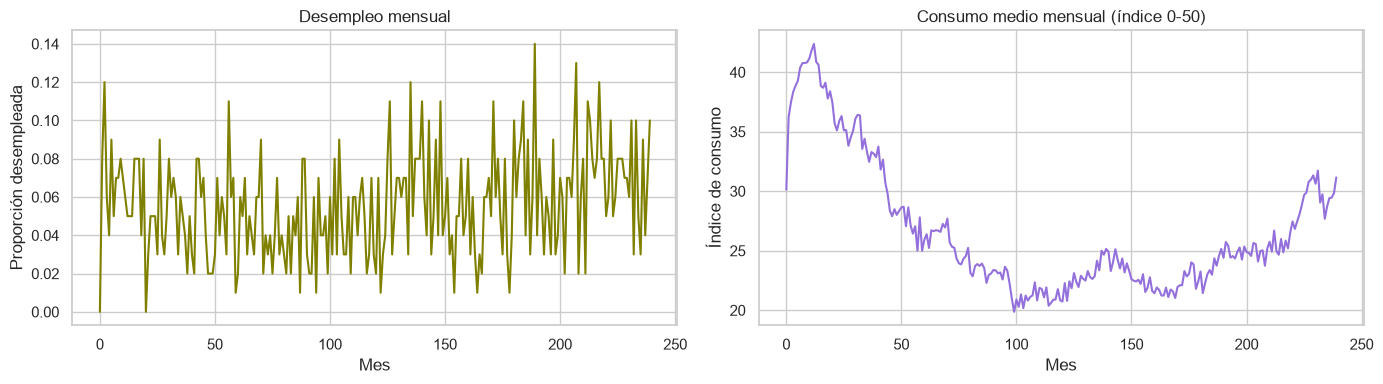

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(unemp_rate_t, color='olive')
axes[0].set_title('Desempleo mensual')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Proporción desempleada')

axes[1].plot(cons_mean_t, color='mediumpurple')
axes[1].set_title('Consumo medio mensual (índice 0-50)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Índice de consumo')

plt.tight_layout()
plt.show()

**Test 1 — agregado, con los 240 meses**: ¿el consumo medio cae cuando sube el desempleo agregado ese mes?

In [17]:
r_agg, p_agg = pearsonr(unemp_rate_t, cons_mean_t)
print(f'Correlación desempleo mensual vs. consumo medio mensual: r={r_agg:.3f}  p={p_agg:.4f}')
print('Si r es cercano a 0 o positivo, el consumo agregado NO está cayendo cuando sube el desempleo')
print('(lo que rompe el mecanismo que produce el signo correcto de Phillips).')

Correlación desempleo mensual vs. consumo medio mensual: r=0.133  p=0.0393
Si r es cercano a 0 o positivo, el consumo agregado NO está cayendo cuando sube el desempleo
(lo que rompe el mecanismo que produce el signo correcto de Phillips).


**Test 2 — individual, dentro de cada mes**: los agentes que ESE mes están desempleados, ¿consumen menos que los que trabajan?

In [18]:
diffs = []
for t in range(T_a):
    w, cc = work_raw[t], cons_raw[t]
    if (w == 0).sum() > 0 and (w == 1).sum() > 0:
        diffs.append(cc[w == 1].mean() - cc[w == 0].mean())

diffs = np.array(diffs)
print(f'Meses con al menos un agente desempleado: {len(diffs)} / {T_a}')
print(f'Diferencia media (consumo empleados - consumo desempleados): {diffs.mean():.2f}  (std {diffs.std():.2f})')
print('Si esta diferencia es chica, los agentes desempleados NO recortan su consumo')
print('respecto a los empleados ese mismo mes.')

Meses con al menos un agente desempleado: 238 / 240
Diferencia media (consumo empleados - consumo desempleados): 0.86  (std 7.80)
Si esta diferencia es chica, los agentes desempleados NO recortan su consumo
respecto a los empleados ese mismo mes.


## 13. La propensión cruda del LLM (antes del sorteo Bernoulli)

`SimpleLabor` en `dense_log` es el resultado *ya discretizado*: `simulate.py` toma la propensión continua que devuelve el LLM (`p_i^w`, 0 a 1) y hace `l_i = Bernoulli(p_i^w)` ([simulate.py:137](simulate.py#L137)). Para ver qué está diciendo el modelo realmente (no el resultado del sorteo), parseamos el JSON crudo `{"work": ..., "consumption": ...}` directamente de `dialogs/*` — un archivo de texto por agente con las 240 respuestas en orden cronológico.

In [19]:
import re

dialog_files = sorted((run_path / 'dialogs').iterdir())
pattern = re.compile(r'"work"\s*:\s*([0-9.]+).*?"consumption"\s*:\s*([0-9.]+)', re.S)

if len(dialog_files) != n_agents:
    print(f'AVISO: {len(dialog_files)} archivos en dialogs/ pero n_agents={n_agents} según el dense_log '
          f'(probablemente quedaron archivos de un intento previo en el mismo directorio de datos; '
          f'no afecta las métricas basadas en states/actions, sólo agrega columnas de más acá).')

work_prop = np.full((T_a, len(dialog_files)), np.nan)
cons_prop = np.full((T_a, len(dialog_files)), np.nan)

for col, fp in enumerate(dialog_files):
    text = fp.read_text(encoding='utf-8', errors='ignore')
    matches = pattern.findall(text)
    for row, (w, c) in enumerate(matches[:T_a]):
        work_prop[row, col] = float(w)
        cons_prop[row, col] = float(c)

print(f'Agentes parseados: {len(dialog_files)}   Meses por agente: {work_prop.shape[0]}')
print(f'Propensión de trabajo (0-1):  media {np.nanmean(work_prop):.4f}  std {np.nanstd(work_prop):.4f}  '
      f'min {np.nanmin(work_prop):.2f}  max {np.nanmax(work_prop):.2f}')
print(f'1 - propensión media de trabajo: {1 - np.nanmean(work_prop):.3%}  '
      f'(comparar con tasa de desempleo real: {unemp_rate_t.mean():.3%})')
print(f'Propensión de consumo (0-1): media {np.nanmean(cons_prop):.4f}  std {np.nanstd(cons_prop):.4f}')


AVISO: 133 archivos en dialogs/ pero n_agents=100 según el dense_log (probablemente quedaron archivos de un intento previo en el mismo directorio de datos; no afecta las métricas basadas en states/actions, sólo agrega columnas de más acá).


Agentes parseados: 133   Meses por agente: 240
Propensión de trabajo (0-1):  media 0.9483  std 0.0613  min 0.40  max 1.00
1 - propensión media de trabajo: 5.173%  (comparar con tasa de desempleo real: 5.571%)
Propensión de consumo (0-1): media 0.5282  std 0.3431


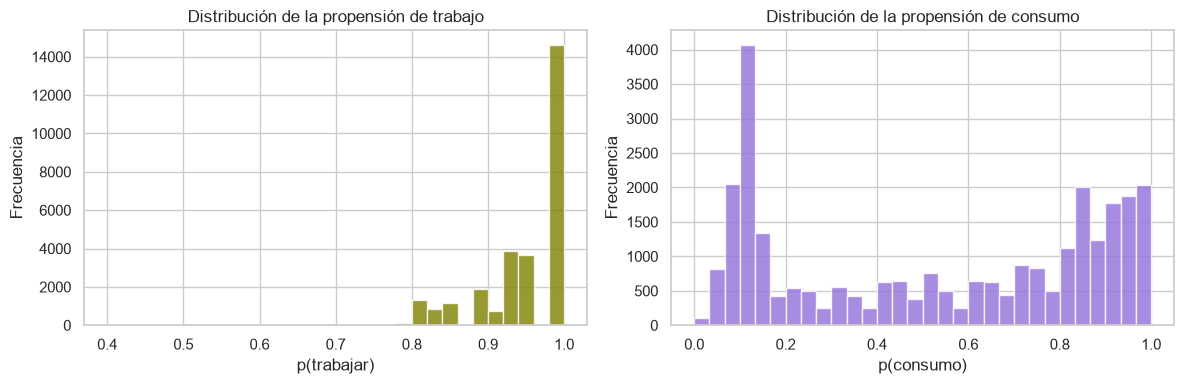

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(work_prop.flatten(), bins=30, color='olive', alpha=0.8)
axes[0].set_title('Distribución de la propensión de trabajo')
axes[0].set_xlabel('p(trabajar)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(cons_prop.flatten(), bins=30, color='mediumpurple', alpha=0.8)
axes[1].set_title('Distribución de la propensión de consumo')
axes[1].set_xlabel('p(consumo)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Lectura** (a confirmar con los números impresos arriba, van a diferir de la corrida original gpt-3.5/ACL24-EconAgent): si la propensión de trabajo está comprimida cerca de 1, el modelo casi no expresa reticencia real a trabajar y el sorteo Bernoulli genera poco desempleo estructural — eso explicaría una banda de desempleo angosta frente al 2-12% del paper.

**Test 3 — mensual, con la propensión continua (240 puntos, no 20 anuales)**: ¿la propensión de consumo cae cuando la propensión de trabajo (agregada) baja, es decir, cuando el mercado laboral está más flojo?

In [21]:
work_prop_t = np.nanmean(work_prop, axis=1)
cons_prop_t = np.nanmean(cons_prop, axis=1)

r_prop, p_prop = pearsonr(work_prop_t, cons_prop_t)
print(f'Correlación propensión de trabajo vs. propensión de consumo (mensual, N={T_a}): r={r_prop:.3f}  p={p_prop:.4f}')
print('r>0 esperable: cuando el mercado labora está más flojo (menos propensión a trabajar),')
print('la propensión de consumo también cae -> eso SÍ generaría el signo correcto de Phillips.')
print('r~0 o negativo indicaría que el consumo no reacciona (o reacciona al revés) al ánimo laboral agregado.')

Correlación propensión de trabajo vs. propensión de consumo (mensual, N=240): r=-0.056  p=0.3842
r>0 esperable: cuando el mercado labora está más flojo (menos propensión a trabajar),
la propensión de consumo también cae -> eso SÍ generaría el signo correcto de Phillips.
r~0 o negativo indicaría que el consumo no reacciona (o reacciona al revés) al ánimo laboral agregado.
